# DISRA Science Case Module

**NAME:** EXOEARTH_SURVEY

**GOAL:** Determine the occurrence rate of Earth-like conditions on rocky worlds around Sun-like stars.

**OBJECTIVE:** Find at least 1 Earth-like planet with $<$characteristic$>$ (e.g., water vapor) orbiting a solar-type star (at Y% confidence) for occurrence rates $\eta_{x} \gtrsim$ X% by discovering and studying $\gtrsim$ Z habitable planet candidates.

**CODE PURPOSE:** Calculate constraint on the measured occurrence rate of water vapor as a function of the number of habitable exoplanet candidates discovered in a high-contrast reconaissance survey.

**BACKGROUND:**

Definition of habitable planet candidate (from LUVOIR Final Report):

1. Solar-type stars have FGK
spectral types
2. Planet orbit within stars’ habitable zones (semi-major axis $0.95 \leq a \leq 1.67$ AU for Sun-twin star, scaled by $\sqrt{L_{\star}/L_\odot}$ for other spectral types)
3. Planet likely to be rocky (planet radius $\leq 1.4 \ R_{Earth}$)
4. Planet likely to retain atmospheres over geologic times (planet radius $\geq 0.8 \, a^{-0.5} \ R_{Earth}$)
5. Planet likely to be Earth-like (geometric albedo = 0.2 between 550–1000 nm)

Sampling uncertainties and uncertainty in the occurrence rate of exoEarth candidates ($\eta_\oplus$) taken into account in Panel 2 plots.

**MODIFICATION HISTORY:**

[2025-01-03] Started by Aki Roberge (AR; aki.roberge@nasa.gov)

[2025-03-31] Heatmap plot for Panel 1A created by AR

# Setup

In [1]:
%matplotlib inline
import os
import math
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import ticker
from matplotlib.colors import ListedColormap
from pathlib import Path
import scipy
from scipy.stats import binom
from scipy.stats import bootstrap
import astropy
import astropy.units as u
#from google.colab import files
#from google.colab import drive
#drive.mount('/content/drive')

# Definition of Functions

In [2]:
def heatmap(data, row_labels, col_labels, ax=None, cbar_kw=None, cbarlabel="", **kwargs):
    """
    Create a heatmap from a numpy array and two lists of labels.

    Parameters
    ----------
    data
        A 2D numpy array of shape (M, N).
    row_labels
        A list or array of length M with the labels for the rows.
    col_labels
        A list or array of length N with the labels for the columns.
    ax
        A `matplotlib.axes.Axes` instance to which the heatmap is plotted.  If
        not provided, use current Axes or create a new one.  Optional.
    cbar_kw
        A dictionary with arguments to `matplotlib.Figure.colorbar`.  Optional.
    cbarlabel
        The label for the colorbar.  Optional.
    **kwargs
        All other arguments are forwarded to `imshow`.
    """

    if ax is None:
        ax = plt.gca()

    if cbar_kw is None:
        cbar_kw = {}

    # Plot the heatmap
    im = ax.imshow(data, **kwargs)

    # Create colorbar
    cbar = ax.figure.colorbar(im, ax=ax, **cbar_kw)
    cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom")

    # Show all ticks and label them with the respective list entries.
    ax.set_xticks(range(data.shape[1]), labels=col_labels,
                  rotation=30, ha="right", rotation_mode="anchor")
    ax.set_yticks(range(data.shape[0]), labels=row_labels)

    # Turn spines off and create white grid.
    ax.spines[:].set_visible(False)

    ax.set_xticks(np.arange(data.shape[1]+1)-.5, minor=True)
    ax.set_yticks(np.arange(data.shape[0]+1)-.5, minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=3)
    ax.tick_params(which="minor", bottom=False, left=False)

    return im, cbar


In [3]:
def annotate_heatmap(im, data=None, valfmt="{x:.2f}", textcolors=("black", "white"),
                     threshold=None, **textkw):
    """
    A function to annotate a heatmap.

    Parameters
    ----------
    im
        The AxesImage to be labeled.
    data
        Data used to annotate.  If None, the image's data is used.  Optional.
    valfmt
        The format of the annotations inside the heatmap.  This should either
        use the string format method, e.g. "$ {x:.2f}", or be a
        `matplotlib.ticker.Formatter`.  Optional.
    textcolors
        A pair of colors.  The first is used for values below a threshold,
        the second for those above.  Optional.
    threshold
        Value in data units according to which the colors from textcolors are
        applied.  If None (the default) uses the middle of the colormap as
        separation.  Optional.
    **kwargs
        All other arguments are forwarded to each call to `text` used to create
        the text labels.
    """

    if not isinstance(data, (list, np.ndarray)):
        data = im.get_array()

    # Normalize the threshold to the images color range.
    if threshold is not None:
        threshold = im.norm(threshold)
    else:
        threshold = im.norm(data.max())/2.

    # Set default alignment to center, but allow it to be
    # overwritten by textkw.
    kw = dict(horizontalalignment="center",
              verticalalignment="center")
    kw.update(textkw)

    # Get the formatter in case a string is supplied
    if isinstance(valfmt, str):
        valfmt = mpl.ticker.StrMethodFormatter(valfmt)

    # Loop over the data and create a `Text` for each "pixel".
    # Change the text's color depending on the data.
    texts = []
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            kw.update(color=textcolors[int(im.norm(data[i, j]) > threshold)])
            text = im.axes.text(j, i, valfmt(data[i, j], None), **kw)
            texts.append(text)

    return texts

# Science Return vs. Observation Quality (Panel 1)

**PHYSICAL PARAMETERS:** Required numbers of habitable exoplanet candidates (survey quality) to find at least one Earth-like planet or constrain the occurrence rate of Earth-like planets (science return).

**OBSERVATIONS:** High-contrast surveys producing different numbers of habitable planet candidates. V band imaging at 3 epochs, followed by a spectrum with 20% bandwidth centered at ~950 nm to detect water vapor and/or methane. See LUVOIR Final Report.

**METHOD:** Using the binomial distribution function, calculate the required number of habitable exoplanet candidates $(N_{HEC})$ to find at least one Earth-like planet at varying confidence levels (C) and as a function of the (unknown) occurrence rate of Earth-like exoplanets $(\eta_{x})$.

$\hspace{1in} N_{HEC} = \frac{\log{(1 - C)}}{\log{(1 - \eta_x)}}\hspace{0.5in}$ Equation 3 in Stark et al. (2014), ApJ, 751, 122

**RESULT:** Heatmap with required numbers of habitable planet candidates as functions of confidence and $\eta_{x}$.

In [4]:
eta_arr = np.arange(0.05, 0.55, 0.05)
conf_arr = np.flip(np.array([0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.997]))
cand_arr = np.zeros((len(conf_arr),len(eta_arr)))
for i in range(len(conf_arr)):
  for j in range(len(eta_arr)):
    cand_arr[i,j] = (np.log10(1. - conf_arr[i]))/(np.log10(1 - eta_arr[j]))

In [5]:
cmp_big = mpl.colormaps['YlGnBu']
newcmp = ListedColormap(cmp_big(np.linspace(0.5, 1.0, 128)))

**Panel 1A - Heatmap**

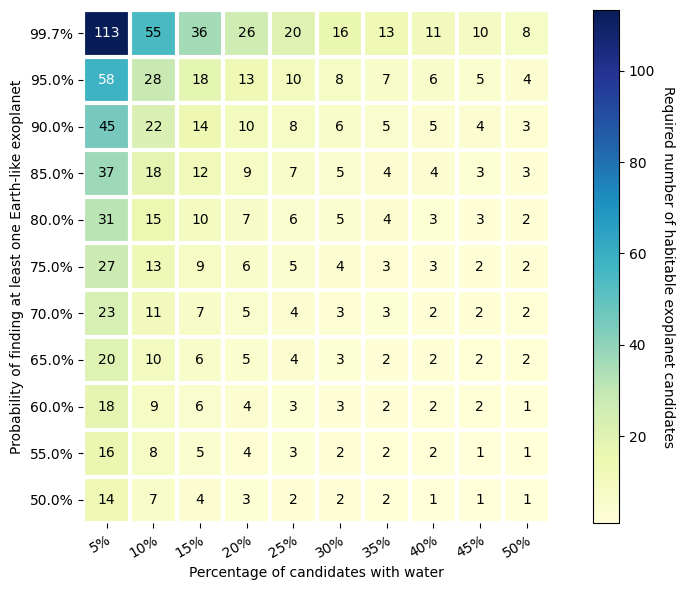

In [6]:
#filename = 'exoearth-survey_panel1_plot1.pdf'

str_eta_arr = [f"{x:.0f}"+"%" for x in eta_arr*100]
str_conf_arr = [f"{x:.1f}"+"%" for x in conf_arr*100]

fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111)
ax.set_xlabel('Percentage of candidates with water')
ax.set_ylabel('Probability of finding at least one Earth-like exoplanet')
im, cbar = heatmap(cand_arr, str_conf_arr, str_eta_arr, ax=ax, cmap='YlGnBu', cbarlabel='Required number of habitable exoplanet candidates')
texts = annotate_heatmap(im, valfmt="{x:.0f}")
fig.tight_layout()
#plt.savefig(os.path.join(figpath, filename), bbox_inches='tight')
#contents = os.listdir(figpath)
#if filename in contents:
#  print(f"{filename} successfully saved to {figpath}")
#else:
#  print(f"Error: {filename} not found in {figpath}")
#files.download(os.path.join(figpath, filename))   # Optional command to download file to your default download location on your local machine
plt.show()

In [7]:
n, p, size = 28, 0.1, 200000
rng = np.random.default_rng()
fail = np.sum(rng.binomial(n=n, p=p, size=size) == 0)/size
print('Probability of at least one success in '+str(n)+' trials if success probability is '+str(p*100)+'% = '+str(np.round(100 - fail*100,1))+'%')

Probability of at least one success in 28 trials if success probability is 10.0% = 94.7%


# Observation Quality vs. Observatory Characteristics (Panel 2) - IN PROGRESS


**BACKGROUND:**

Panel 1 shows how many habitable planet candidates must be actually observed by a survey to achieve certain science returns. However, the "same" survey will not produce the same yield of habitable planet candidates every time, due to the stochastic nature of small number statistics. To ensure a certain required yield at high confidence, we will need a **survey yield target (Z$_T$)** that is higher than the required yield (Z from Panel 1).

One way of estimating Z$_T$ is to use "P25". This is the probability that a survey produces at least 25 habitable planet candidates, and represents our confidence that the survey will meet our needs. P25 is calculated by running the same survey many times and seeing what fraction of them delivered $> 25$ candidates.

**OBSERVATIONS:**

Survey yield target Z$_T$ = expectation value of survey yield

P25 = probability that a survey with expectation value Z$_T$ produces 25 habitable planet candidates

In [8]:
# Including all astrophysical uncertainties except eta_earth (Chris Stark's "Goal A")
# Figure 26 from Stark et al. (2024)
Z_target = np.array([17.3468, 20.0351, 23.8331, 24.5376, 29.2604, 31.6386, 34.2840, 37.4687, 38.8990, 48.7478])
P25 = np.array([0.0628594, 0.176442, 0.434679, 0.487735, 0.788610, 0.883185, 0.939404, 0.976592, 0.986857, 0.999739])

In [9]:
import numpy as np
import scipy.interpolate as interp
import scipy.io
from astropy import units as u
import matplotlib.pyplot as plt
%matplotlib inline

# And now the DISRA imports
from hwo_disra.api.notebook_api import DisraNBApi
from hwo_disra.Types import Time, ScienceYield, ScienceValue, Range, DiscretePoints, SinglePoint

import eacy

  points: [1136.3 1142.3 1142.4 1142.5 1152.7]
  lookup_table: [-9.31015728e-07 -2.34371190e-07 -2.17769838e-06 -1.89383420e-06
 -1.86404638e-07] [synphot.models]
  points: [1170.     1170.5    1171.3    ... 2241.1    2241.2001 2241.3   ]
  lookup_table: [-3.99896421e-07 -3.16809265e-06 -1.49050587e-06 ... -8.56435582e-07
 -9.55618745e-07 -4.15987490e-08] [synphot.models]
  points: [1180.5 1181.5 1241.5 1244.5 1248.5 1249.5 1262.5 1290.5 1307.5 1310.5
 1312.5 1315.5 1316.5 1317.5 1318.5 1321.5 1330.5 1333.5 1341.5 1342.5
 1343.5 1345.5 1346.5 1348.5 1352.5 1370.5 1372.5 1379.5 1380.5 1384.5
 1386.5 1387.5 1388.5 1389.5 1391.5 1395.5 1399.5 1400.5 1426.5 1427.5
 1428.5 1429.5 1434.5 1447.5 1448.5 1449.5 1450.5 1454.5 1455.5 1456.5
 1461.5 1466.5 1474.5 1475.5 1482.5 1493.5 1498.5 1505.5 1519.5 1539.5
 1558.5 1563.5 1567.5 1569.5 1570.5 1575.5 1577.5 1579.5 1581.5 1582.5
 1584.5 1589.5 1590.5 1591.5 1592.5 1594.5 1595.5 1596.5 1599.5 1600.5
 1601.5 1605.5 1606.5 1607.5 1608.5 1609.5 1612

In [10]:
def stark2014(lim_mag, nexozod, contrast, iwa, diameter):
    dat = scipy.io.readsav('stark-yields/DISRA_exoplanet_yield_grid_Stark_2014.sav') #read in data table from Stark+2014
    npl = dat['np']
    #print(dat)
    #print(dat.shape)
    npl = npl[:,0,:,:,:,:] #ignore eta_earth column; use scaling law from Stark+2015
    pos = (dat['limiting_magnitude_factor_list'], dat['nexozodis_list'], np.log10(dat['contrast_list']), dat['iwafactor_list'], 1./dat['d_list'])
    pos2 = (np.array([lim_mag]), np.array([nexozod]), np.array([contrast]), np.array([iwa]), np.array([1./diameter]))
    return(scipy.interpolate.interpn(pos, npl, pos2)) #return linear interpolation

In [11]:
def stark2015(lim_mag=1, nexozod=3, contrast=1e-10, iwa=3.6, diameter=6, eta_earth=0.1, albedo=0.2, throughput=0.2, bandwidth=0.1, PSF_elongation=1.0, OWA=15, T_total=1, SNR=7):
    yield1 = stark2014(lim_mag, nexozod, np.log10(contrast), iwa, diameter)
    #need to scale 2014 results (SNR = 10) to SNR = 7
    yield1 *= (7./10.)**-0.76 #scaling yield results from SNR 10 needed (2014) to SNR 7 needed (2015)
    #Apply other scaling laws using 2015 scaling rules, which match 2014 starting conditions (other than SNR). Diameter is drawn from the lookup table, so not concerned with that scaling.
    yield1 *= (eta_earth/0.1)**0.96 #eta_earth in fractional units
    yield1 *= (albedo/0.2)**0.65 #geometric albedo scaling
    yield1 *= (throughput/0.2)**0.35 #throughput through system scaling, in fractional units
    yield1 *= (bandwidth/0.1)**0.3 #bandwidth, in fractional units
    yield1 *= (PSF_elongation/1.0)**-0.33 #PSF broadening of planet signal
    yield1 *= (OWA/15)**0.07 #outer working angle in lambda/D
    yield1 *= (T_total/1)**0.32 #exposure time of the mission in years
    yield1 *= (SNR/7)**-0.76 #required signal-to-noise ratio

    return yield1

In [12]:
stark2014(1,3,-10,3,6)

array([5.70325382])

## Yield variations with coronagraph parameters

In [13]:
outer_working_angle = np.arange(10, 25, 1) #outer working angle extent = 10 - 25 λ/D in 1 λ/D increments
inner_working_angle = np.arange(1, 5, 0.5) #inner working angle extent = 1 - 5 λ/D in 0.5 λ/D increments

k = np.zeros((len(outer_working_angle), len(inner_working_angle)))
for i in range(len(outer_working_angle)):
  for j in range(len(inner_working_angle)):
      k[i,j] = stark2015(diameter = 6, throughput = 0.3, lim_mag = 1, SNR = 7, eta_earth = 0.24, T_total = 2, iwa = inner_working_angle[j], OWA = outer_working_angle[i])[0]


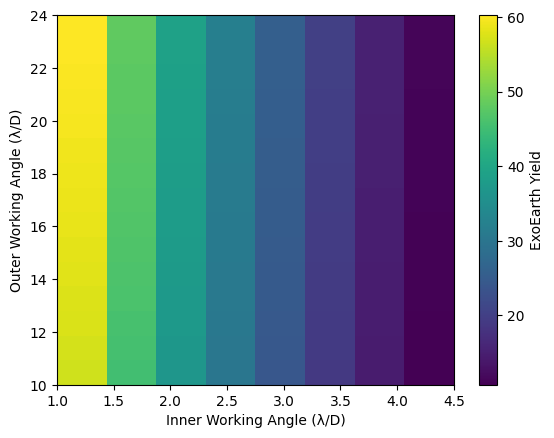

In [14]:
plt.imshow(k, extent = [min(inner_working_angle), max(inner_working_angle), min(outer_working_angle), max(outer_working_angle)], aspect = 'auto', origin = 'lower')
plt.xlabel('Inner Working Angle (λ/D)')
plt.ylabel('Outer Working Angle (λ/D)')
plt.colorbar(label='ExoEarth Yield')
#plt.imshow(k)

## DISRA portion

Now we use the above two functions to create a DISRA case.

The actual purpose of the science case is find at least one Earth-like planet or constrain the occurrence rate of Earth-like planets. That is the science return.
For the purposes of DISRA, however, we are trying to evaluate the effectiveness of different EACs and instruments at *performing* a study capable of answering that question. So how do we design this survey?

The output of DISRA is discrete values of time, as a function of yield.

### For the Yieldinator: 
Figure 1 is given above, a parameterization of the number of exoplanets required to achieve the goal of the study, completely independent of the telescope, where "Goal" is "Find at least 1 Earth-like exoplanet" and the yield is "To this percent probability".

We have no control over the astrophysical parameters (eta_earth, nexozod, and albedo) for the purposes of this DISRA case those numbers will be fixed at pessimistic values to ensure we're testing the EAC's ability to successfully complete a challenging study.
* nexozod = 3 (Stark et al. 2014)
* eta_earth = 0.1 (as description, and Stark et al. (2014)) or 0.25 (per discussion on 2026-02-27)
* albedo = 0.2 (Stark et al. 2014)

We will also fix SNR at the level estimated to be required in Stark (2015)
* SNR = 7

Per Stark et al. (2014) and analysis above, the most impactful other parameters to vary are the telescope diameter (set by the EAC) and the telescope inner working angle. We will keep other parameters at the values used in Stark et al. (2014), which were used in the computation of the original table.
* lambda: 0.55 $\mu$m
* Band width: 0.11 $\mu$m
* OWA: 15 $\lambda\over D$
* Contrast: $1e^{-10}$
* Photometry Radius: 0.7 $\lambda\over D$

In [15]:
desired = 1

nexozod = 3
eta_earth = 0.1
albedo = 0.2
snr = 7
owa = 15
contrast = 1e-10

### For the Timeinator:
For Figure 2, we need to confront the actual telescope model.

Instrument diameter and throughput are not exactly fixed, but are generally properties of the EAC itself; they will be inputs but ones the DISRA machinery itself does not vary over.
* diameter = Set by EAC (via EACy)
* throughput = Set by EAC (via EACy)

The values that will vary are:
* IWA (1 - 5 $\lambda\over D$)

The other special value here is time. The Stark table interpolation uses time as an input (as T_total) and yield (exoplanets detected) as an output; time is therefore one of the parameters we will vary over, in order to find the optimal time to complete a survey.

Of the remaining parameters in consideration, the one with the highest impact is IWA.

The first pass at a Figure 2 will therefore be a parameterization of time versus IWA; all other parameters held to defaults.

In [16]:
iwas = np.linspace(1,5,10)

# A custom yieldinator

In [17]:
from scipy.stats import Binomial

api = DisraNBApi.get_instance()

def compute_yield(probability, samples, iwa, desired) -> ScienceYield:
    trials = 50000
    
    fail = np.sum(rng.binomial(n=samples, p=p, size=trials) == 0)/trials
    success = 1 - fail
    #func = Binomial(n=int(samples), p=probability)
    # ccdef gives the probability that the measurement will be desired or higher
    #success = func.ccdf(desired)

    
    return ScienceYield(success*100)

In [18]:
compute_yield(0.1,28,1,1)

np.float64(94.66)

[7.061224489795918, 11.102040816326529, 29.285714285714285, 55.55102040816326]


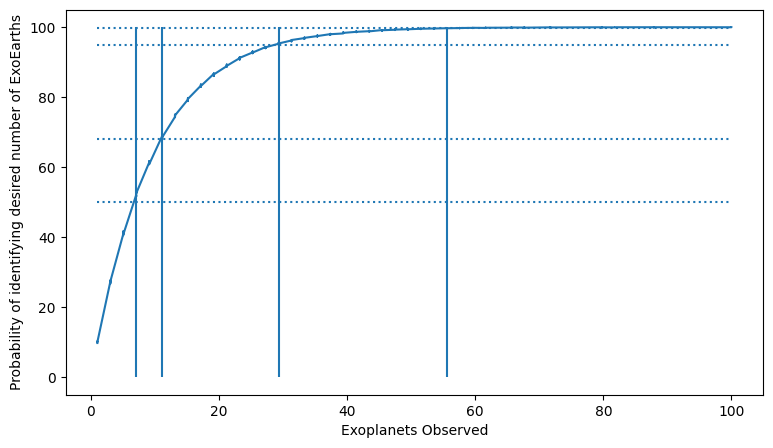

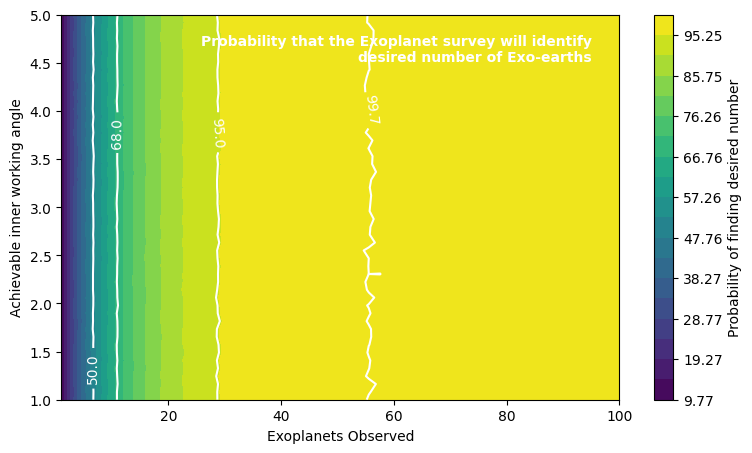

In [19]:
instrument = "CI"
detector = "IMAGER"

yieldinator = api.yieldinator(name="exoEarth survey", variables = {"probability": SinglePoint(eta_earth), "samples": Range(1,100, 'samples'), "iwa": Range(1,5, "iwa"), "desired": SinglePoint(desired)},
                                            yield_function = compute_yield,
                                            thresholds = {ScienceValue.STATE_OF_THE_ART: ScienceYield(50), 
                                                          ScienceValue.ENHANCING: ScienceYield(68), # 1-sigma
                                                          ScienceValue.ENABLING: ScienceYield(95), # 2-sigma
                                                          ScienceValue.BREAKTHROUGH: ScienceYield(99.7) # 3-sigma
                                                         }
                            )
eval_results = api.evaluate(yieldinator, register=True)
#print(eval_results)

results = []
samples = []
for sample_point in eval_results[0].sample_points:
    results.append(sample_point.yield_result)
    samples.append(sample_point.variable_values["samples"])

results = np.asarray(results)

fig = plt.figure(figsize=(9,5))
ax = fig.add_subplot(111)
ax.plot(samples, results)
lines = []
for threshold_value in yieldinator.thresholds().values():
    lines.append(samples[np.argmin(np.abs(results-threshold_value))])

#lines = np.isclose(results,list(yieldinator.thresholds().values()))
print(lines)
ax.hlines(yieldinator.thresholds().values(), np.min(samples), np.max(samples), linestyle="dotted")
ax.vlines(lines, 0, 100)
ax.set_xlabel("Exoplanets Observed")
ax.set_ylabel("Probability of identifying desired number of ExoEarths")
plt.show()

#api.bar_plot(eval_results

api.contour_plot_yield(eval_results, x_key ='samples', y_key ='iwa', z_key ='yield_result',
                       contour_levels=sorted(yieldinator.thresholds().values()),
                       figsize = (9, 5),
                       axis_labels = {'iwa': 'Achievable inner working angle', 'samples': 'Exoplanets Observed',
                                            'yield_result': 'Probability of finding desired number'},
                       titles = ['Probability that the Exoplanet survey will identify\ndesired number of Exo-earths'])


In [20]:
def load_from_eacy(eac):
    # use EACy to load the parameters for the coronagraphic instrument.
    parameters = eacy.collate(eac.name.upper(), instrument, detector, "pickle", save=False)
    diameter = parameters["diam_insc"]

    tel_refl = np.nanmean(parameters["total_tele_refl"])
    inst_refl = np.nanmean(parameters["total_inst_refl"])

    throughput = tel_refl * inst_refl
    #print(throughput)
    
    return diameter, throughput

In [21]:
import astropy.units as u

def compute_time(eac, yield_value, probability, samples, desired, iwa) -> Time:
    # In this situation, the stark yield calculator's OUTPUT is yield, and INPUT is time.
    # We therefore want to precompute a table of our own so we can interpolate to get time = f(yield)

    # Use EACy to load the coronagraphic throughputs
    eac_diameter, eac_throughput = load_from_eacy(eac)

    # The stark2015 time is in mission-years
    times = np.arange(0.01,5,0.01)
    yields = []
    for time in times:
        yields.append(stark2015(diameter = eac_diameter, nexozod=nexozod, throughput = eac_throughput, iwa=iwa, albedo = albedo, lim_mag = 1, SNR = snr, eta_earth = probability, T_total = time)[0])
    
    interpolator = interp.make_interp_spline(yields, times)
    time = interpolator(yield_value) * u.year
    return time.to_value(u.second)

In [22]:
timeinator = api.timeinator(yieldinator, timeinate=compute_time)

evaluations = api.evaluate(timeinator, steps = 10, register=True)

Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That was EACy!
Done! That wa

KeyError: 'diam_insc'